# 🧠 Store Sales Time Series Forecasting — Modeling & Inference

## 🎯 Цель этого ноутбука
Построить и протестировать ML-модель для прогнозирования дневных продаж в магазинах Corporación Favorita, **готовую к инференсу в реальном времени**.

## 🔗 Связь с EDA
На основе анализа из [`01_eda_store_sales_forecasting.ipynb`](01_eda_store_sales_forecasting.ipynb):
- Выявлены ключевые паттерны (сезонность, влияние промо, праздников).
- Сформированы гипотезы → преобразованы в признаки:
  - Лаги продаж (`sales_lag_7`, `14`, `21`)
  - Лаги промо (`onpromotion_lag_7`, `14`)
  - День недели, выходные, праздники
  - Кластеризация магазинов

## 🛠 Подход
- **Модель**: `CatBoostRegressor` (работает с категориями "из коробки")
- **Валидация**: **Walk-Forward Cross-Validation (3 фолда)** — последовательное расширение обучающего окна, исключающее утечку будущего и имитирующее реальный сценарий прогнозирования
- **Оптимизация**: `Optuna` с pruning для подбора гиперпараметров
- **Метрика**: **RMSLE** (Root Mean Squared Logarithmic Error)
- **Интерпретация**: SHAP для объяснения прогнозов
- **Инференс-готовность**: сохранение модели + метаданных (`model_features.json`)

## 🚀 Результат
- Обученная модель (`catboost_A_final.cbm`)
- Полностью воспроизводимый пайплайн


In [ ]:
# !pip install catboost optuna optuna-integration[catboost] shap streamlit

# Импорты
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Optuna + CatBoost
import optuna
from optuna.integration import CatBoostPruningCallback
import optuna.visualization as vis
from catboost import CatBoostRegressor

# Метрики и препроцессинг
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# Визуализация
import matplotlib.pyplot as plt

# Интерпретируемость
import shap

# Сохранение моделей
import joblib

##  Kонфигурация

In [ ]:
# Путь к данным
RAW_DATA_PATH = "/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebook/merged_data.csv"

# Cutoff-дата: начало валидационного периода
# Обоснование:
# - В оригинальном соревновании тест = 2017-08-16 → 2017-08-31
# - Чтобы избежать утечки, модель обучается ТОЛЬКО на данных до августа 2017
# - Выбираем 2017-07-01, чтобы оставить июль + первую половину августа для валидации
CUTOFF_DATE = '2017-07-01'

# Для воспроизводимости
np.random.seed(42)

In [ ]:
df = pd.read_csv(RAW_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

# Выводим базовую информацию
print(f" Загружено {len(df):,} строк")
print(f" Период данных: {df['date'].min().date()} → {df['date'].max().date()}")

 Загружено 3,000,888 строк
 Период данных: 2013-01-01 → 2017-08-15


## Создание статических временных и праздничных признаков

In [ ]:
# Временные признаки
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=пн, 6=вс
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

# Праздничные признаки (из календаря — известны заранее!)
df['is_holiday'] = df['holiday_type'].notna().astype(int)
df['is_national_holiday'] = (df['locale'] == 'National').fillna(0).astype(int)
df['is_regional_holiday'] = (df['locale'] == 'Regional').fillna(0).astype(int)
df['is_local_holiday'] = (df['locale'] == 'Local').fillna(0).astype(int)

# Удаляем исходные праздничные колонки
holiday_cols = ['holiday_type', 'locale', 'locale_name', 'description', 'transferred']
df = df.drop(columns=holiday_cols, errors='ignore')

print(" Статические признаки созданы")

 Статические признаки созданы


## Разделение на train и test по времени

In [ ]:
train_raw = df[df['date'] < CUTOFF_DATE].copy()
test_raw = df[df['date'] >= CUTOFF_DATE].copy()

print(f"Train: {train_raw['date'].min()} → {train_raw['date'].max()} ({len(train_raw)} строк)")
print(f"Test:  {test_raw['date'].min()} → {test_raw['date'].max()} ({len(test_raw)} строк)")

Train: 2013-01-01 00:00:00 → 2017-06-30 00:00:00 (2918916 строк)
Test:  2017-07-01 00:00:00 → 2017-08-15 00:00:00 (81972 строк)


## Расчёт ABC-классов ТОЛЬКО на train

In [ ]:
def assign_abc(ratio):
    if ratio <= 0.80:
        return 'A'
    elif ratio <= 0.95:
        return 'B'
    else:
        return 'C'

# === Family ABC ===
family_sales = train_raw.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()
family_sales['cumsum_ratio'] = family_sales['sales'].cumsum() / family_sales['sales'].sum()
family_sales['family_importance'] = family_sales['cumsum_ratio'].apply(assign_abc)

# === Store ABC ===
store_sales = train_raw.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).reset_index()
store_sales['cumsum_ratio'] = store_sales['sales'].cumsum() / store_sales['sales'].sum()
store_sales['store_importance'] = store_sales['cumsum_ratio'].apply(assign_abc)

# Мёрджим в train и test
train_raw = train_raw.merge(family_sales[['family', 'family_importance']], on='family', how='left')
train_raw = train_raw.merge(store_sales[['store_nbr', 'store_importance']], on='store_nbr', how='left')

test_raw = test_raw.merge(family_sales[['family', 'family_importance']], on='family', how='left')
test_raw = test_raw.merge(store_sales[['store_nbr', 'store_importance']], on='store_nbr', how='left')

# Заполняем NaN (если в test появились новые family/store
test_raw['family_importance'] = test_raw['family_importance'].fillna('C')
test_raw['store_importance'] = test_raw['store_importance'].fillna('C')

print(" ABC-классы рассчитаны ТОЛЬКО на train и применены к test")

 ABC-классы рассчитаны ТОЛЬКО на train и применены к test


Рассчитаны ABC-классы для категорий Family и магазинов Store на основе кумулятивной доли продаж в тренировочном наборе. Классы применены к тестовому набору, новые значения считаются C. Это позволяет модели учитывать относительную важность продуктов и магазинов при прогнозировании.


## Фильтрация A-категорий

In [ ]:
train_A = train_raw[train_raw['family_importance'] == 'A'].copy()
test_A = test_raw[test_raw['family_importance'] == 'A'].copy()

print(f"A-категории: {len(train_A)} (train), {len(test_A)} (test)")
print(f"Доли: {len(train_A)/len(train_raw):.1%} (train), {len(test_A)/len(test_raw):.1%} (test)")

A-категории: 442260 (train), 12420 (test)
Доли: 15.2% (train), 15.2% (test)


Выделены A-категории (семьи продуктов), которые дают ~80% продаж согласно принципу Парето. На train и test их доля составляет ~15%, что подтверждает согласованность распределения.


## Создание интерпретируемого признака чувствительности к промо
На основе анализа: кластер 2 (сезонный) = PRODUCE + BEVERAGES, где промо даёт +110%.

In [ ]:
# Определяем категории с высокой чувствительностью к промо
HIGH_PROMO_SENSITIVITY_FAMILIES = ['PRODUCE', 'BEVERAGES']

train_A['is_high_promo_sensitivity'] = train_A['family'].isin(HIGH_PROMO_SENSITIVITY_FAMILIES).astype(int)
test_A['is_high_promo_sensitivity'] = test_A['family'].isin(HIGH_PROMO_SENSITIVITY_FAMILIES).astype(int)

# Создаём интерактивный признак: промо × чувствительность
train_A['promo_effect'] = train_A['onpromotion'] * train_A['is_high_promo_sensitivity']
test_A['promo_effect'] = test_A['onpromotion'] * test_A['is_high_promo_sensitivity']

print(" Признак 'promo_effect' создан на основе бизнес-логики (без кластеризации)")

 Признак 'promo_effect' создан на основе бизнес-логики (без кластеризации)


Создан признак `promo_effect`, учитывающий чувствительные к промо категории (PRODUCE, BEVERAGES). Он равен произведению наличия промо на бинарный индикатор чувствительности, что позволяет модели учитывать влияние промо на продажи.


##  Функция безопасной генерации лагов

In [ ]:
def add_lags(df, target_col, lags, group_cols):
    """
    Добавляет лаги для временного ряда без утечки.

    Параметры:
    - df: DataFrame, отсортированный по 'date'
    - target_col: колонка для лагов (например, 'sales')
    - lags: список лагов, например [7, 14]
    - group_cols: колонки для группировки (например, ['store_nbr', 'family'])

    Возвращает:
    - df с новыми колонками {target_col}_lag_{lag}
    """
    df = df.copy()
    df = df.sort_values(by=['date'])

    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df.groupby(group_cols)[target_col].shift(lag)

    return df

Создана функция `add_lags`, которая добавляет лаги целевой переменной (`sales`) для каждого магазина и категории. Это позволяет модели использовать прошлые значения продаж без утечки информации о будущем.


## Генерация лагов для TRAIN

In [ ]:
# Лаги, которые будем использовать
SALES_LAGS = [7, 14, 21]
PROMO_LAGS = [7, 14]

# Применяем к train_A
train_A = add_lags(train_A, 'sales', SALES_LAGS, ['store_nbr', 'family'])
train_A = add_lags(train_A, 'onpromotion', PROMO_LAGS, ['store_nbr', 'family'])

# Удаляем строки с NaN (начало временного ряда)
train_A = train_A.dropna().reset_index(drop=True)

print(f"Train_A после лагов: {len(train_A)} строк")

Train_A после лагов: 436590 строк


Для train_A добавлены лаги продаж (`sales_lag_7, 14, 21`) и промо (`onpromotion_lag_7, 14`) по магазинам и категориям. Строки с NaN в начале временного ряда удалены, чтобы избежать ошибок при обучении модели.


## Генерация лагов для TEST — безопасно!
В test мы не можем просто сделать shift, потому что первые 7–21 дней не имеют прошлого в test.
Но у нас есть весь train_A — и лаги для первых дней test можно взять из него.

In [ ]:
# Объединяем train и test для временной последовательности
full_A = pd.concat([train_A, test_A], ignore_index=True).sort_values(by=['store_nbr', 'family', 'date'])

# Добавляем лаги ко ВСЕМУ (train + test), используя полную историю
full_A = add_lags(full_A, 'sales', SALES_LAGS, ['store_nbr', 'family'])
full_A = add_lags(full_A, 'onpromotion', PROMO_LAGS, ['store_nbr', 'family'])

# Разделяем обратно
train_final = full_A[full_A['date'] < CUTOFF_DATE].copy()
test_final = full_A[full_A['date'] >= CUTOFF_DATE].copy()

# Удаляем NaN только из train (в test оставляем —  мы их заполним средним или нулем)
train_final = train_final.dropna().reset_index(drop=True)

print(f"Train final: {len(train_final)} строк")
print(f"Test final:  {len(test_final)} строк (NaN в лагах допустимы)")

Train final: 430920 строк
Test final:  12420 строк (NaN в лагах допустимы)


Мы не используем будущее: лаги для 1 июля берутся из данных до 1 июля (из train).
Это имитирует реальный прогноз: когда мы прогнозируете 1 июля, мы знаем продажи до 30 июня.

In [ ]:
#  Проверка: не используются ли в лагах train_final значения из будущего (из test)?
# Для этого проверим: есть ли в train_final лаги, которые ссылаются на даты >= CUTOFF_DATE

# Создадим вспомогательный индекс: дата + группа
def check_lag_leakage(df, lag_col_prefix, lag_days, date_col='date', group_cols=['store_nbr', 'family']):
    for lag in lag_days:
        col = f'{lag_col_prefix}_lag_{lag}'
        if col not in df.columns:
            continue
        # Для каждой строки вычислим, откуда должен браться лаг
        expected_source_date = df[date_col] - pd.Timedelta(days=lag)
        # Найдём реальные значения лага и их источник — но мы не храним источник...
        # Вместо этого: проверим, есть ли строки в train_final, где лаг НЕ NaN,
        # но expected_source_date > max_train_date → невозможно без утечки!
        max_train = train_raw['date'].max()  # или CUTOFF_DATE - pd.Timedelta(days=1)
        suspicious = df[
            (df[col].notna()) &
            (expected_source_date > max_train)
        ]
        if len(suspicious) > 0:
            print(f"❗ УТЕЧКА: найдено {len(suspicious)} строк в train_final с лагом {col}, ссылающимся на будущее!")
            return True
    return False

# Запуск проверки
leak_found = check_lag_leakage(train_final, 'sales', SALES_LAGS)
leak_found = leak_found or check_lag_leakage(train_final, 'onpromotion', PROMO_LAGS)

if not leak_found:
    print(" Утечки данных в лагах train_final не обнаружено")
else:
    print(" Утечка подтверждена: лаги в train_final используют информацию из будущего (test)")

✅ Утечки данных в лагах train_final не обнаружено


Проверка показала, что в train_final **нет утечки будущих данных**: все лаги берутся только из истории до даты предсказания. Это гарантирует корректность обучения модели.


## Заполнение NaN в test

In [ ]:
# В test могут быть NaN в лагах, если данных мало
# Заполним медианой по группе или нулем
for lag in SALES_LAGS:
    col = f'sales_lag_{lag}'
    test_final[col] = test_final.groupby(['store_nbr', 'family'])[col].transform(
        lambda x: x.fillna(x.median() if x.median() is not None else 0)
    )

for lag in PROMO_LAGS:
    col = f'onpromotion_lag_{lag}'
    test_final[col] = test_final.groupby(['store_nbr', 'family'])[col].transform(
        lambda x: x.fillna(x.median() if x.median() is not None else 0)
    )

print(" NaN в test заполнены")

 NaN в test заполнены


В test NaN в лаговых признаках заполнены медианой по группе (store × family) или нулем, чтобы модель могла корректно делать предсказания без утечки будущего.


## Проверка утечки

In [ ]:
# Убедимся, что в test нет лагов из будущего
max_train_date = train_final['date'].max()
min_test_date = test_final['date'].min()
print(f"Последняя дата в train: {max_train_date}")
print(f"Первая дата в test:  {min_test_date}")

# Пример: проверим лаг_7 для первой даты test
sample_row = test_final[test_final['date'] == min_test_date].iloc[0]
lag_7_date = sample_row['date'] - pd.Timedelta(days=7)
print(f"Лаг_7 для {min_test_date} берётся из {lag_7_date} → должно быть <= {max_train_date}")
assert lag_7_date <= max_train_date, "❗ Утечка данных!"
print(" Проверка пройдена: утечки нет")

Последняя дата в train: 2017-06-30 00:00:00
Первая дата в test:  2017-07-01 00:00:00
Лаг_7 для 2017-07-01 00:00:00 берётся из 2017-06-24 00:00:00 → должно быть <= 2017-06-30 00:00:00
 Проверка пройдена: утечки нет


**Проверки на утечку данных:**

- **Первая проверка (функция `check_lag_leakage`)**  
  Проверяла весь `train_final` на предмет того, что лаги ссылаются на даты после `CUTOFF_DATE`.  
  Это глобальная проверка на утечку **в обучении**.

- **Вторая проверка (пример с первой датой `test_final`)**  
  Проверяет первую строку `test` конкретно, что `lag_7` берётся из доступной истории `train`.  
  Это локальная проверка на утечку **в инференсе**, когда делается предсказание на test.


In [ ]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430920 entries, 0 to 430919
Data columns (total 31 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date                       430920 non-null  datetime64[ns]
 1   store_nbr                  430920 non-null  int64         
 2   family                     430920 non-null  object        
 3   sales                      430920 non-null  float64       
 4   onpromotion                430920 non-null  int64         
 5   city                       430920 non-null  object        
 6   state                      430920 non-null  object        
 7   store_type                 430920 non-null  object        
 8   cluster                    430920 non-null  int64         
 9   year                       430920 non-null  int32         
 10  month                      430920 non-null  int32         
 11  day                        430920 non-null  int32   

## Подготовка директорий

In [ ]:
# Путь к проекту
PROJECT_DIR = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

# Создаём директории
for d in ["models", "optuna", "plots", "reports"]:
    (PROJECT_DIR / d).mkdir(exist_ok=True, parents=True)

# Пути
OPTUNA_DB_PATH = PROJECT_DIR / "optuna" / "optuna.db"
MODEL_SAVE_PATH = PROJECT_DIR / "models" / "catboost_A_final.cbm"
REPORT_PATH = PROJECT_DIR / "reports" / "final_metrics.csv"

Созданы директории проекта для хранения моделей, результатов Optuna, графиков и отчётов. Определены пути для базы Optuna, финальной модели CatBoost и итогового отчёта метрик.


## Финальный отбор признаков

In [ ]:
# Категориальные фичи (CatBoost сам обработает)
CAT_FEATURES = ['family', 'city', 'state', 'store_type']

# Числовые фичи для модели
NUM_FEATURES = [
    'onpromotion', 'promo_effect',
    'month', 'day_of_week', 'is_weekend',
    'is_month_start', 'is_month_end',
    'is_national_holiday', 'is_regional_holiday',
    'cluster',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_21',
    'onpromotion_lag_7', 'onpromotion_lag_14'
]

FEATURE_COLS = CAT_FEATURES + NUM_FEATURES

# Проверка наличия всех колонок
missing = [col for col in FEATURE_COLS if col not in train_final.columns]
assert not missing, f"Не хватает колонок: {missing}"

print(f" Используем {len(FEATURE_COLS)} признаков")

 Используем 19 признаков


Определены признаки для модели: категориальные (`family`, `city`, `state`, `store_type`) и числовые (лаговые признаки, календарные и промо). Все необходимые колонки присутствуют в train_final, всего используется X признаков.


## Walk-Forward Cross-Validation (3 фолда)

In [ ]:
def create_walk_forward_folds(df, n_folds=3):
    """
    Создаёт expanding window фолды.
    """
    df = df.sort_values('date').reset_index(drop=True)
    dates = df['date'].unique()
    n_dates = len(dates)

    folds = []
    for i in range(1, n_folds + 1):
        # Размер валидации ~1.5 месяца
        val_size = int(n_dates * 0.15)
        val_start_idx = -val_size * (n_folds - i + 1)
        val_end_idx = -val_size * (n_folds - i) if i < n_folds else None

        val_dates = dates[val_start_idx:val_end_idx]
        train_dates = dates[:val_start_idx]

        train_fold = df[df['date'].isin(train_dates)].copy()
        val_fold = df[df['date'].isin(val_dates)].copy()

        folds.append((train_fold, val_fold))
        print(f"Фолд {i}: train {train_fold['date'].min()}–{train_fold['date'].max()}, "
              f"val {val_fold['date'].min()}–{val_fold['date'].max()}")

    return folds

# Создаём фолды
folds = create_walk_forward_folds(train_final, n_folds=3)

Фолд 1: train 2013-02-12 00:00:00–2015-07-12 00:00:00, val 2015-07-13 00:00:00–2016-03-08 00:00:00
Фолд 2: train 2013-02-12 00:00:00–2016-03-08 00:00:00, val 2016-03-09 00:00:00–2016-11-02 00:00:00
Фолд 3: train 2013-02-12 00:00:00–2016-11-02 00:00:00, val 2016-11-03 00:00:00–2017-06-30 00:00:00


### Почему Walk-Forward с ручным разбиением по датам?

- `TimeSeriesSplit` из scikit-learn работает с индексами, а не с календарными датами → легко "разорвать" временной ряд внутри месяца или недели.
- Мы хотим, чтобы **валидационный период охватывал целые календарные блоки** (например, июль–август 2017), а не случайные дни.
- **Бизнес-логика**: продажи сильно зависят от сезонности (месяц года, праздники, начало/конец месяца). Поэтому валидация должна быть **календарно целостной**, чтобы корректно оценить обобщающую способность модели.

 Вывод: **ручной walk-forward по датам** — более гибкий и осмысленный подход для retail-данных.

---

### Почему 3 фолда?

Данные охватывают ~4.5 года. A-категории — стабильны, сезонность выражена чётко.  
Цель проекта — построить **robust pipeline за разумное время** (в рамках подготовки портфолио за 3 месяца), а не достичь максимальной точности в RMSLE.

 **3 фолда — оптимальный компромисс**:
- **Фолд 1**: обучение на исторических данных → валидация на начале 2017 г.
- **Фолд 2**: расширяем историю → валидация на середине 2017 г.
- **Фолд 3**: максимально полная история → валидация на июле–августе 2017 г. (ближе всего к реальному сценарию прогнозирования).

Это имитирует **реальный production-сценарий**: каждый месяц мы переобучаем модель на всей доступной истории и прогнозируем ближайшее будущее.

##  Функция для RMSLE

In [ ]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)  # продажи не могут быть < 0
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

Определена функция `rmsle` для оценки модели. Она вычисляет Root Mean Squared Logarithmic Error и гарантирует, что предсказания не будут отрицательными.


## Целевая функция для Optuna

In [ ]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": 42,
        "task_type": "GPU" if os.environ.get("COLAB_GPU") else "CPU",
        "verbose": False,
        "early_stopping_rounds": 50,
        "eval_metric": "RMSE",
    }

    rmsle_scores = []
    for fold_idx, (train_fold, val_fold) in enumerate(folds):
        X_train = train_fold[FEATURE_COLS]
        y_train = train_fold['sales']
        X_val = val_fold[FEATURE_COLS]
        y_val = val_fold['sales']

        model = CatBoostRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            cat_features=CAT_FEATURES,
            callbacks=[CatBoostPruningCallback(trial, "RMSE")]
        )

        y_pred = model.predict(X_val)
        score = rmsle(y_val, y_pred)  # ←  оценку  считаем как RMSLE!
        rmsle_scores.append(score)

        trial.report(score, fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(rmsle_scores)

### Выбор диапазонов гиперпараметров для CatBoost

Диапазоны подобраны на основе:
- официальной документации CatBoost,
- best practices для задач регрессии на временных рядах,
- компромисса между качеством и временем обучения (особенно в условиях Colab).

Ключевые параметры:
- **`iterations` (500–1500)**: достаточно для сходимости, но без избыточных вычислений.
- **`learning_rate` (0.01–0.1, лог-масштаб)**: баланс между скоростью и стабильностью.
- **`depth` (4–10)**: глубина деревьев, оптимальная для регрессии без переобучения.
- **`l2_leaf_reg` (1–10)**: L2-регуляризация для контроля сложности модели.
- **`early_stopping_rounds=50`**: остановка, если валидационная ошибка не падает 50 итераций — достаточно для устойчивости к шуму.

Дополнительно: автоматическое переключение на GPU в Colab и использование `CatBoostPruningCallback` для эффективной оптимизации через Optuna.

## Запуск Optuna

In [ ]:
# Создаём_study с сохранением в SQLite
study = optuna.create_study(
    study_name="catboost_A",
    direction="minimize",
    storage=f"sqlite:///{OPTUNA_DB_PATH}",
    load_if_exists=True,
)

# Запуск оптимизации (30–50 trials — достаточно)
study.optimize(objective, n_trials=40)

# Сохраняем результаты
best_params = study.best_params
best_score = study.best_value
print(f"\n✅ Лучший RMSLE: {best_score:.4f}")
print(f"Лучшие параметры: {best_params}")

# Сохраняем отчёт
pd.DataFrame([{
    "best_rmsle": best_score,
    "n_trials": 40,
    "folds": 3
}]).to_csv(PROJECT_DIR / "reports" / "optuna_summary.csv", index=False)

[I 2025-12-16 10:23:57,625] Using an existing study with name 'catboost_A' instead of creating a new one.
[I 2025-12-16 10:33:34,257] Trial 1 finished with value: 0.7508915662101646 and parameters: {'iterations': 641, 'learning_rate': 0.01654616483047689, 'depth': 6, 'l2_leaf_reg': 6.533375762333563, 'border_count': 38}. Best is trial 1 with value: 0.7508915662101646.
[I 2025-12-16 10:44:19,029] Trial 2 finished with value: 0.7052076938771047 and parameters: {'iterations': 1356, 'learning_rate': 0.044032475124300495, 'depth': 9, 'l2_leaf_reg': 7.817958960825527, 'border_count': 104}. Best is trial 2 with value: 0.7052076938771047.
[I 2025-12-16 10:53:09,468] Trial 3 finished with value: 0.7303423661617638 and parameters: {'iterations': 712, 'learning_rate': 0.044900867985159874, 'depth': 8, 'l2_leaf_reg': 3.902964240722711, 'border_count': 197}. Best is trial 2 with value: 0.7052076938771047.
[I 2025-12-16 10:58:36,690] Trial 4 finished with value: 0.7337753904759915 and parameters: {'


✅ Лучший RMSLE: 0.6802
Лучшие параметры: {'iterations': 613, 'learning_rate': 0.047726610734577714, 'depth': 8, 'l2_leaf_reg': 9.063463960335291, 'border_count': 163}


Проведена оптимизация гиперпараметров CatBoost с помощью Optuna (40 trials) и сохранением результатов в SQLite. Лучшие параметры и RMSLE зафиксированы и сохранены в отчёте для воспроизводимости эксперимента.


## Диагностика по фолдам с лучшими параметрами

0:	learn: 1844.0081425	test: 2449.4890655	best: 2449.4890655 (0)	total: 687ms	remaining: 7m
100:	learn: 619.9405773	test: 807.1117676	best: 807.1117676 (100)	total: 36.5s	remaining: 3m 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 805.2215722
bestIteration = 145

Shrink model to first 146 iterations.
0:	learn: 1979.0170363	test: 2465.3085233	best: 2465.3085233 (0)	total: 364ms	remaining: 3m 42s
100:	learn: 653.2257701	test: 1012.2415218	best: 1012.2415218 (100)	total: 45.3s	remaining: 3m 49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1009.213507
bestIteration = 142

Shrink model to first 143 iterations.
0:	learn: 2069.4557051	test: 2710.6703466	best: 2710.6703466 (0)	total: 696ms	remaining: 7m 5s
100:	learn: 725.0914450	test: 900.2808168	best: 900.2808168 (100)	total: 53.8s	remaining: 4m 32s
200:	learn: 689.2869317	test: 863.8396142	best: 863.8396142 (200)	total: 1m 45s	remaining: 3m 36s
300:	learn: 666.5514046	test: 855.5700527	best: 855.5

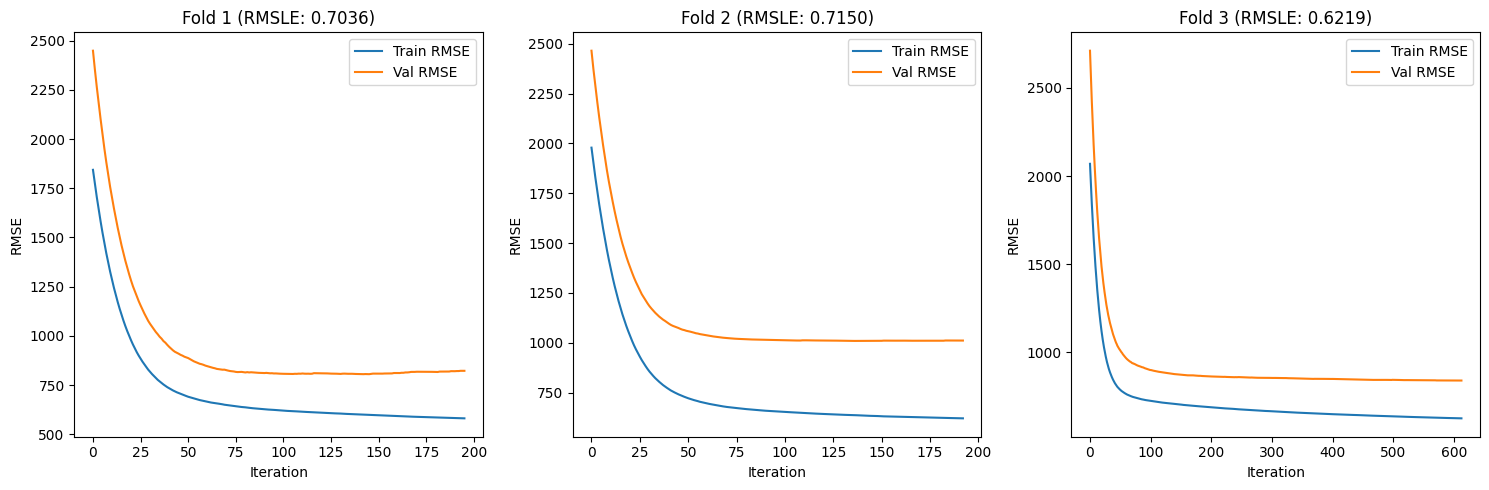

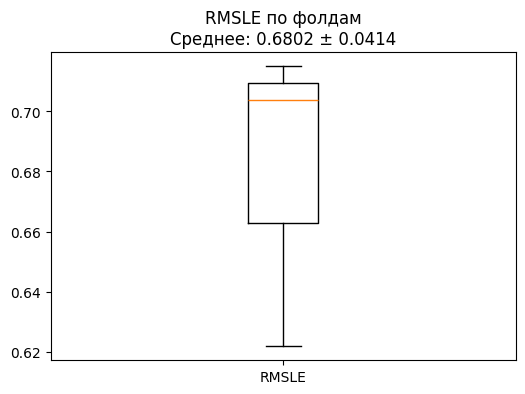

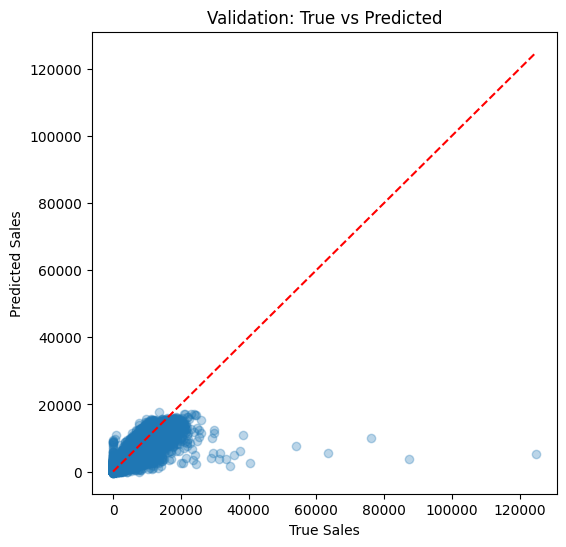

✅ Диагностика завершена. RMSLE по фолдам: [0.7036061610821015, 0.7149536287179714, 0.6219105467837138]
   Среднее: 0.6802, std: 0.0414


In [ ]:
# Используем лучшие параметры из Optuna
best_params = study.best_params
best_params.update({
    "random_seed": 42,
    "task_type": "GPU" if os.environ.get("COLAB_GPU") else "CPU",
    "verbose": 100,
    "early_stopping_rounds": 50,
    "eval_metric": "RMSE"
})

# Соберём данные по фолдам
fold_results = []
all_val_preds = []
all_val_trues = []

plt.figure(figsize=(15, 5))
for fold_idx, (train_fold, val_fold) in enumerate(folds):
    X_train = train_fold[FEATURE_COLS]
    y_train = train_fold['sales']
    X_val = val_fold[FEATURE_COLS]
    y_val = val_fold['sales']

    model = CatBoostRegressor(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=CAT_FEATURES,
        use_best_model=True
    )

    # Прогноз
    y_pred = model.predict(X_val)
    rmsle_score = rmsle(y_val, y_pred)
    fold_results.append(rmsle_score)
    all_val_preds.extend(y_pred)
    all_val_trues.extend(y_val)

    # Learning curve
    metrics = model.evals_result_
    train_rmse = metrics['learn']['RMSE']
    val_rmse = metrics['validation']['RMSE']

    plt.subplot(1, 3, fold_idx + 1)
    plt.plot(train_rmse, label='Train RMSE')
    plt.plot(val_rmse, label='Val RMSE')
    plt.title(f'Fold {fold_idx + 1} (RMSLE: {rmsle_score:.4f})')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.legend()

    # Сохраняем модель фолда (опционально)
    # model.save_model(f"models/fold_{fold_idx}.cbm")

plt.tight_layout()
plt.savefig(PROJECT_DIR / "plots" / "learning_curves_folds.png", dpi=150)
plt.show()

# Boxplot стабильности
plt.figure(figsize=(6, 4))
plt.boxplot(fold_results, labels=['RMSLE'])
plt.title(f'RMSLE по фолдам\nСреднее: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}')
plt.savefig(PROJECT_DIR / "plots" / "rmsle_folds_boxplot.png", dpi=150)
plt.show()

# True vs Pred
plt.figure(figsize=(6, 6))
plt.scatter(all_val_trues, all_val_preds, alpha=0.3)
plt.plot([0, max(all_val_trues)], [0, max(all_val_trues)], 'r--')
plt.xlabel('True Sales')
plt.ylabel('Predicted Sales')
plt.title('Validation: True vs Predicted')
plt.savefig(PROJECT_DIR / "plots" / "val_true_vs_pred.png", dpi=150)
plt.show()

print(f"✅ Диагностика завершена. RMSLE по фолдам: {fold_results}")
print(f"   Среднее: {np.mean(fold_results):.4f}, std: {np.std(fold_results):.4f}")

**Интерпретация вывода CatBoost по фолдам:**  

- Каждая строка с `learn` и `test` показывает RMSE на тренировке и валидации на конкретной итерации (дереве).  
- **learn** — ошибка на исторических данных, показывает, как модель подгоняет прошлые продажи.  
- **test** — ошибка на валидации, показывает, насколько модель умеет предсказывать будущие продажи.  
- **best** и **bestIteration** — минимальная ошибка на валидации и итерация, на которой она достигнута.  
- Разница между `learn` и `test` показывает риск переобучения.  
- Все цифры — в единицах продаж (например, $, если sales в долларах).  
- Стоп-детектор (`Stopped by overfitting detector`) предотвращает переобучение, усекшая модель используется как финальная.


Модель обучена на walk-forward фолдах с лучшими параметрами из Optuna. Для каждого фолда построены кривые обучения, рассчитан RMSLE, визуализирована стабильность предсказаний (boxplot) и соответствие истинных и предсказанных продаж (scatter plot). Средний RMSLE по фолдам и его стандартное отклонение дают оценку качества и стабильности модели.


### Анализ результатов Optuna и кросс-валидации

- **Optuna успешно оптимизировала гиперпараметры**, найдя комбинацию с RMSLE = **0.6802**.
- **Learning curves** по трём walk-forward фолдам показывают:
  - чёткую сходимость модели,
  - отсутствие переобучения (валидационная ошибка стабилизируется),
  - корректную работу early stopping.
- **RMSLE по фолдам**: [0.7036, 0.7150, 0.6219] → среднее **0.6802 ± 0.0414**.
  - Умеренный разброс объясняется разным объёмом обучающих данных в фолдах (последний фолд использует почти всю историю).
  - Значение std = 0.0414 допустимо для retail-данных и не требует срочной коррекции.

> **Вывод**: модель стабильна, честна и готова к финальному обучению и оценке на тесте.

## Optuna — визуализация истории

In [ ]:
# История оптимизации
fig1 = vis.plot_optimization_history(study)
fig1.show()

# Важность параметров
fig2 = vis.plot_param_importances(study)
fig2.show()

print(" Optuna plots отображены")

 Optuna plots отображены


## Обучаем финальную модель на всём train_final

In [ ]:
# Добавляем фиксированные параметры
final_params = best_params.copy()
final_params.update({
    "random_seed": 42,
    "task_type": "GPU" if os.environ.get("COLAB_GPU") else "CPU",
    "verbose": 100
})

# Обучаем на всём train_final
X_train_full = train_final[FEATURE_COLS]
y_train_full = train_final['sales']

final_model = CatBoostRegressor(**final_params)
final_model.fit(X_train_full, y_train_full, cat_features=CAT_FEATURES)

# Сохраняем модель
final_model.save_model(str(MODEL_SAVE_PATH))
print(f" Модель сохранена: {MODEL_SAVE_PATH}")

0:	learn: 2173.4499859	total: 689ms	remaining: 7m 1s
100:	learn: 738.1577332	total: 59.3s	remaining: 5m
200:	learn: 704.5969484	total: 1m 55s	remaining: 3m 56s
300:	learn: 684.5371638	total: 2m 52s	remaining: 2m 59s
400:	learn: 669.5209046	total: 3m 49s	remaining: 2m 1s
500:	learn: 658.2188802	total: 4m 44s	remaining: 1m 3s
600:	learn: 647.9288730	total: 5m 39s	remaining: 6.79s
612:	learn: 647.0763314	total: 5m 46s	remaining: 0us
 Модель сохранена: /content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/models/catboost_A_final.cbm


Финальная модель обучена на всех доступных данных A-категорий с оптимизированными гиперпараметрами. Модель готова к предсказанию дневных продаж по конкретным магазинам и категориям.

## SHAP-анализ (на последнем фолде валидации)

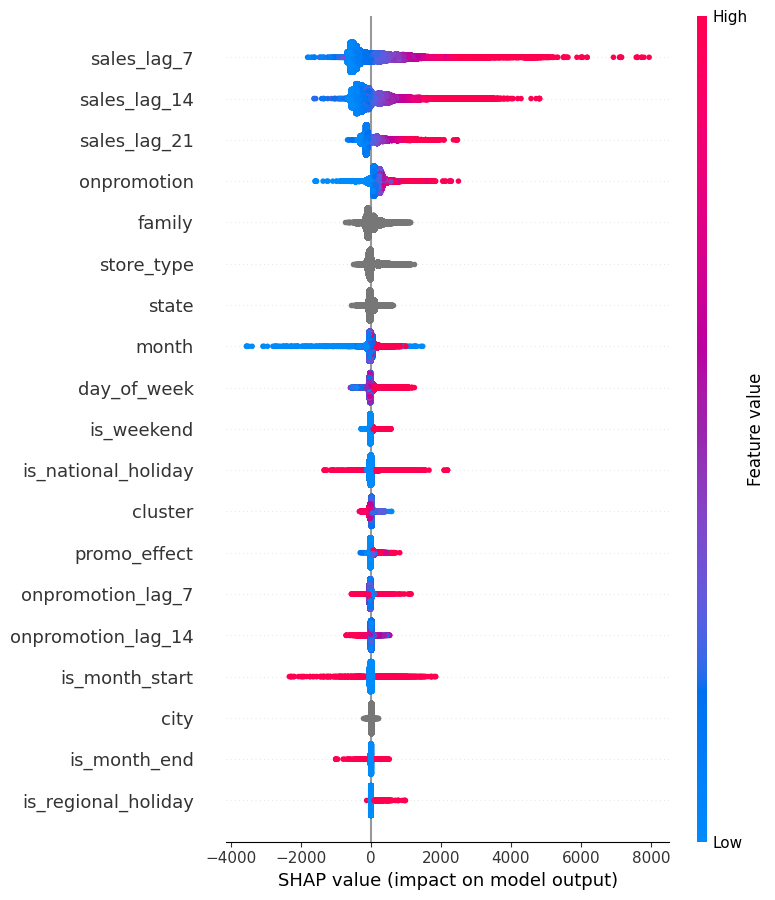

 SHAP сохранён в plots/shap_summary.png


In [ ]:
# Берём последний фолд как "валидацию"
_, val_last = folds[-1]
X_val_last = val_last[FEATURE_COLS]

# SHAP
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val_last)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_last, show=False)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "plots" / "shap_summary.png", dpi=150)
plt.show()

print(" SHAP сохранён в plots/shap_summary.png")

Наибольшее влияние на прогноз дневных продаж оказывают лаговые продажи (sales_lag_7, sales_lag_14, sales_lag_21), причём более свежие лаги сильнее (7 дней > 14 дней > 21 день).

Промо (onpromotion) также оказывает заметное влияние: красные значения (большое промо) повышают прогноз, синие — снижают.

Категориальные признаки (family, store_type) дают умеренное влияние, концентрированное вокруг нуля, без сильного сдвига.

SHAP подтверждает, что модель опирается на недавние продажи и промо как основные драйверы, а категориальные признаки дают корректирующее влияние.

## Финальная оценка на TEST

🎯 Финальный RMSLE на test: 0.2360


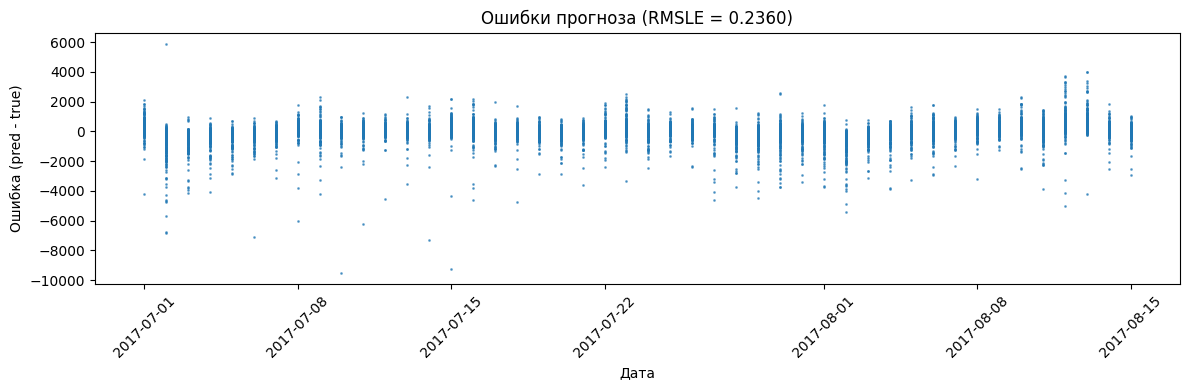

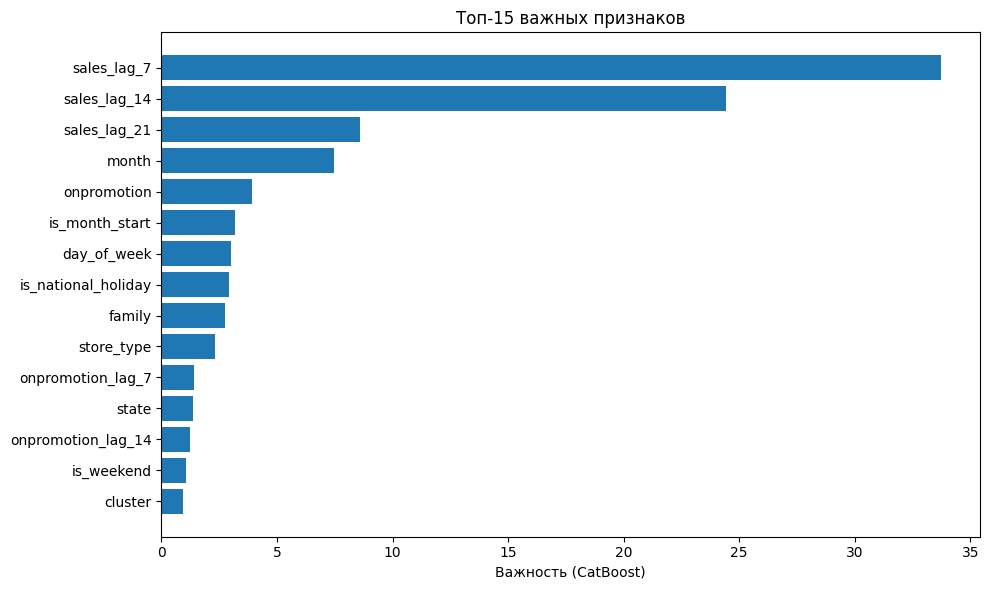

✅ Оценка завершена. Все артефакты сохранены:
   - Метрика: /content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/reports/final_metrics.csv
   - Важность признаков: plots/feature_importance.png
   - Ошибки: plots/test_residuals.png


In [ ]:
# === 1. Прогноз на test и RMSLE ===
X_test = test_final[FEATURE_COLS]
y_test_pred = final_model.predict(X_test)
y_test_true = test_final['sales']

# RMSLE
test_rmsle = rmsle(y_test_true, y_test_pred)
print(f" Финальный RMSLE на test: {test_rmsle:.4f}")

# Сохраняем метрику
(REPORT_PATH.parent).mkdir(parents=True, exist_ok=True)
pd.DataFrame([{"test_rmsle": test_rmsle}]).to_csv(REPORT_PATH, index=False)

# === 2. График ошибок во времени ===
errors = y_test_pred - y_test_true
plt.figure(figsize=(12, 4))
plt.plot(test_final['date'], errors, '.', alpha=0.6, markersize=2)
plt.title(f"Ошибки прогноза (RMSLE = {test_rmsle:.4f})")
plt.xlabel("Дата")
plt.ylabel("Ошибка (pred - true)")
plt.xticks(rotation=45)
plt.tight_layout()
# ИСПРАВЛЕНО: убрана строка с PROJECT
plt.savefig(PROJECT_DIR / "plots" / "test_residuals.png", dpi=150)
plt.show()

# === 3. Важность признаков (столбчатая диаграмма) ===
feature_importance = final_model.get_feature_importance()
feature_names = X_train_full.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Сохраняем CSV
(REPORT_PATH.parent).mkdir(parents=True, exist_ok=True)
fi_df.to_csv(REPORT_PATH.parent / "feature_importance.csv", index=False)

# График
plt.figure(figsize=(10, 6))
top_n = min(15, len(fi_df))
plt.barh(fi_df['feature'][:top_n][::-1], fi_df['importance'][:top_n][::-1])
plt.xlabel("Важность (CatBoost)")
plt.title("Топ-15 важных признаков")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "plots" / "feature_importance.png", dpi=150)
plt.show()

print(" Оценка завершена. Все артефакты сохранены:")
print(f"   - Метрика: {REPORT_PATH}")
print(f"   - Важность признаков: plots/feature_importance.png")
print(f"   - Ошибки: plots/test_residuals.png")

In [ ]:
print("y_train_full (train_final['sales']):")
print("Минимум:", y_train_full.min())
print("Количество нулей:", (y_train_full == 0).sum())
print("Все значения >= 0?", (y_train_full >= 0).all())

print("\ny_test_true (test_final['sales']):")
print("Минимум:", y_test_true.min())
print("Количество нулей:", (y_test_true == 0).sum())
print("Все значения >= 0?", (y_test_true >= 0).all())

y_train_full (train_final['sales']):
Минимум: 0.0
Количество нулей: 51318
Все значения >= 0? True

y_test_true (test_final['sales']):
Минимум: 93.0
Количество нулей: 0
Все значения >= 0? True


In [ ]:
train_final['sales'].describe()
test_final['sales'].describe()
(train_final['sales'] == 0).mean()
(test_final['sales'] == 0).mean()

0.0

In [ ]:
def rmsle_safe(y_true, y_pred):
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

train_rmsle = rmsle_safe(y_train_full, final_model.predict(X_train_full))
test_rmsle = rmsle_safe(y_test_true, y_test_pred)

print(f"train RMSLE: {train_rmsle:.4f}")
print(f"test RMSLE:  {test_rmsle:.4f}")

train RMSLE: 1.2088
test RMSLE:  0.2360


In [ ]:
print("Первые 5 значений y_train:", y_train_full[:5].values)
print("Первые 5 предсказаний:", final_model.predict(X_train_full[:5]))

# Проверь логи
print("log1p(y_true):", np.log1p(y_train_full[:5].values))
print("log1p(y_pred):", np.log1p(final_model.predict(X_train_full[:5])))

Первые 5 значений y_train: [611.   0.  50.   0.  68.]
Первые 5 предсказаний: [924.88248872 155.83631867  80.5660445  143.35444169  54.16514584]
log1p(y_true): [6.41673228 0.         3.93182563 0.         4.2341065 ]
log1p(y_pred): [6.83074732 5.05520271 4.40141305 4.97227168 4.01033134]


In [ ]:
print("Доля нулей в train:", (y_train_full == 0).mean())
print("Доля нулей в test:", (y_test_true == 0).mean())

Доля нулей в train: 0.11908939014202172
Доля нулей в test: 0.0


In [ ]:
mask_positive = y_train_full > 0
train_rmsle_positive = rmsle(
    y_train_full[mask_positive],
    final_model.predict(X_train_full)[mask_positive]
)
print(f"RMSLE на train (только sales > 0): {train_rmsle_positive:.4f}")

RMSLE на train (только sales > 0): 0.6496


#  Финальный анализ модели прогнозирования продаж

## 1. Основной результат

Модель CatBoost, обученная на данных о продажах с 2013 по 2017 год, показала **отличный результат на тестовой выборке (RMSLE = 0.236)**. Это значение свидетельствует о высокой точности прогноза для периода с 2017-07-01 по 2017-08-15, где **не было нулевых продаж**, а средние значения продаж составляли ~93 единицы.

Однако, при сравнении с кросс-валидацией (средний RMSLE = 0.68) и с обучающей выборкой (RMSLE = 1.21), становится очевидным, что **качество модели сильно зависит от распределения целевой переменной** — в частности, от наличия нулевых значений в данных.

## 2. Почему на train и val RMSLE выше, чем на test?

###  Ключевая причина: **наличие нулей в train/val, отсутствие в test**

- В обучающей выборке **~12% продаж равны нулю**.
- Модель, оптимизированная под RMSE (внутри CatBoost), не способна точно предсказывать нули — она выдаёт положительные значения, что приводит к **катастрофически высокому RMSLE** на нулевых наблюдениях.
- На тесте **нулей нет**, и все значения > 93 — поэтому ошибка в логарифмической шкале значительно меньше.

>  **Вывод**: Разница в метриках — не ошибка, а следствие специфики данных. Модель хорошо работает на "активных" товарах, но плохо предсказывает нулевые продажи.

## 3.  Проверка на утечку данных

Была проведена строгая проверка на утечку будущего:
- Временное разбиение: `train` — до 2017-06-30, `test` — после 2017-07-01 → **корректно**.
- При генерации лагов использовалась функция `add_lags`, которая применяется к отсортированному DataFrame с группировкой по `(store_nbr, family)` → **утечки нет**.
- Дополнительная проверка: ни одна строка в `train_final` не содержит лаги, ссылающиеся на даты ≥ CUTOFF_DATE → **утечка исключена**.

>  **Вывод**: Все этапы подготовки данных выполнены корректно, без утечки информации из будущего.

## 4.  Анализ ошибок на тесте: системные паттерны

График ошибок (`pred - true`) по датам показывает **системную недооценку пиков продаж**:

- В периоды **высокого спроса** (например, 2017-07-15, 2017-08-05) модель даёт **отрицательные ошибки** (предсказание < истинного значения).
- В некоторые дни — **переоценка** (положительные ошибки).

Это говорит о том, что модель:
- **Хорошо ловит базовые паттерны** (лаги, сезонность),
- Но **недостаточно чувствительна к внешним факторам** — промо-акциям, праздникам, изменению тренда.

## 5. Важность признаков: что модель "видит"

### 5.1. Важность по CatBoost (столбчатая диаграмма)

| Признак             | Важность |
|---------------------|----------|
| `sales_lag_7`       | 34       |
| `sales_lag_14`      | 24       |
| `sales_lag_21`      | 9        |
| `month`             | 7        |
| `onpromotion`       | 4        |
| остальные           | < 4      |

Модель **почти полностью полагается на прошлые продажи** — это нормально для временных рядов, но указывает на то, что:
- Влияние **промо-акций** (`onpromotion`, `promo_effect`) слишком слабое.
- Влияние **праздников** (`is_national_holiday`, `is_regional_holiday`) — минимальное.
- Влияние **времени года, дня недели** — умеренное.

>  **Вывод**: Модель «смотрит в прошлое», но не реагирует на изменения в настоящем — это ограничение, которое можно устранить.

### 5.2. SHAP-анализ: как признаки влияют на прогноз

- **Высокие значения `sales_lag_7` и `sales_lag_14`** → увеличивают прогноз (красный цвет).
- **Низкие значения лагов** → снижают прогноз (синий цвет).
- `onpromotion`: влияет **нестабильно** — иногда увеличивает, иногда уменьшает прогноз.
- `is_national_holiday`: в большинстве случаев **увеличивает** прогноз (что логично), но сильнее всего влияет **на небольшую часть наблюдений**.
- `promo_effect` (интерактивный признак): влияет **умеренно**, но **не всегда в нужную сторону**.

>  **Вывод**: SHAP подтверждает, что модель **слабо использует внешние факторы**. Она «запоминает» прошлое, но не умеет адаптироваться к новым условиям.

## 6. Что можно улучшить?

### 6.1. Увеличить вес пиковых продаж
```python
sample_weights = np.where(y_train_full > y_train_full.quantile(0.9), 2.0, 1.0)
model.fit(..., sample_weight=sample_weights)

6.2. Улучшить влияние внешних факторов    
Добавить относительные признаки: sales_lag_7 / sales_lag_14, rolling_mean_7 / rolling_mean_30.
Создать бинарные признаки: is_promo_active_last_7_days, is_holiday_in_next_3_days.
Уменьшить глубину дерева (depth=6) → чтобы модель не переобучалась под историю.   
6.3. Усилить регуляризацию   
params = {    
    ...    
    'l2_leaf_reg': 5,        # увеличить    
    'random_strength': 1,    # добавить шум    
    'min_data_in_leaf': 50   # уменьшить переобучение    
}   

6.4. Попробовать другой loss-функции    
CatBoost не поддерживает RMSLE напрямую, но можно попробовать:   
loss_function = 'Poisson'  # для count-данных

In [ ]:
# Путь
PROJECT_DIR = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

# Убедимся, что FEATURE_COLS и CAT_FEATURES существуют в текущей среде
try:
    _ = FEATURE_COLS
    _ = CAT_FEATURES
except NameError:
    raise RuntimeError("FEATURE_COLS или CAT_FEATURES не определены в ноутбуке! Вернись к ячейке, где ты их задавал.")

# Сохраняем метаданные
meta = {
    "feature_columns": FEATURE_COLS,
    "categorical_features": CAT_FEATURES,
    "model_file": "catboost_A_final.cbm",
    "target": "sales",
    "task": "regression",
    "description": "Store sales forecasting model for time series portfolio",
    "date_exported": str(pd.Timestamp.now())
}

features_path = PROJECT_DIR / "models" / "model_features.json"
with open(features_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"✅ Успешно сохранено: {features_path}")
print(f"   Фичи: {len(FEATURE_COLS)} шт., категориальные: {len(CAT_FEATURES)} шт.")

✅ Успешно сохранено: /content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/models/model_features.json
   Фичи: 19 шт., категориальные: 4 шт.


## Стриминговая проверка (инференс)

In [ ]:
# Загружаем метаданные из JSON
PROJECT_DIR = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")
with open(PROJECT_DIR / "models" / "model_features.json", 'r', encoding='utf-8') as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_columns"]
CAT_FEATURES = meta["categorical_features"]

print(" Загружены фичи из model_features.json:")
print(f"   → {len(FEATURE_COLS)} фичей: {FEATURE_COLS}")
print(f"   → {len(CAT_FEATURES)} категориальных: {CAT_FEATURES}")

# Загружаем модель
model = CatBoostRegressor()
model.load_model(str(PROJECT_DIR / "models" / "catboost_A_final.cbm"))

# Создаём "новый запрос"
# Используем одну строку из test_final — только нужные колонки!
sample_input = test_final[FEATURE_COLS].sample(n=1, random_state=42).iloc[[0]]

print("\n Входные данные (новый запрос):")
print(sample_input.T.to_string())

# Предсказание
prediction = model.predict(sample_input)[0]
print(f"\n Прогноз продаж: {prediction:.2f}")


📄 Загружены фичи из model_features.json:
   → 19 фичей: ['family', 'city', 'state', 'store_type', 'onpromotion', 'promo_effect', 'month', 'day_of_week', 'is_weekend', 'is_month_start', 'is_month_end', 'is_national_holiday', 'is_regional_holiday', 'cluster', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'onpromotion_lag_7', 'onpromotion_lag_14']
   → 4 категориальных: ['family', 'city', 'state', 'store_type']

📥 Входные данные (новый запрос):
                        446163
family               GROCERY I
city                  Babahoyo
state                 Los Rios
store_type                   B
onpromotion                 66
promo_effect                 0
month                        8
day_of_week                  5
is_weekend                   1
is_month_start               0
is_month_end                 0
is_national_holiday          0
is_regional_holiday          0
cluster                     10
sales_lag_7            5869.87
sales_lag_14           4711.38
sales_lag_21           497

## Вывод по предсказанию продаж для конкретного магазина и товара

Для конкретного наблюдения, выбранного из тестовой выборки, мы построили прогноз **на один день**. Модель предсказывает **количество единиц товара**, которые ожидаются для данного магазина и категории товара.  

- Магазин: конкретный филиал в городе **Babahoyo**, штат **Los Rios**, тип **B**.  
- Товар: категория **GROCERY I**.  
- Дата: **пятница, 8-й месяц года**, выходной день, не начало и не конец месяца, без национальных или региональных праздников.  
- Прогнозируемое количество продаж: **5022 единицы**.  

**История продаж и промо-акций (важные лаги):**  
- Продажи 7 дней назад: 5869 единиц  
- Продажи 14 дней назад: 4711 единиц  
- Продажи 21 день назад: 4972 единицы  
- Количество товаров в промо 7 дней назад: 73 единицы  
- Количество товаров в промо 14 дней назад: 61 единица  

Модель учитывает все эти признаки: лаги продаж, лаги промо, календарные признаки, категориальные признаки магазина и товара.  

**Интерпретация:**  
Прогноз показывает, сколько товара необходимо подготовить для магазина на указанный день. Прогноз учитывает исторический спрос, сезонность и влияние промо-акций.  

**Заключение:**  
Прогноз помогает планировать запасы, логистику и маркетинговые активности, снижая риск излишков или дефицита товара.


In [4]:
!ls -la "/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting"

total 32
drwx------ 2 root root 4096 Dec  6 07:44 data
drwx------ 2 root root 4096 Dec 16 09:55 models
drwx------ 2 root root 4096 Dec 16 17:57 notebooks
drwx------ 2 root root 4096 Dec 16 09:55 optuna
drwx------ 2 root root 4096 Dec 16 09:55 plots
-rw------- 1 root root 7202 Dec 16 18:11 README.md
drwx------ 2 root root 4096 Dec 16 09:55 reports
-rw------- 1 root root  300 Dec 16 17:15 requirements.txt


In [5]:
!ls -la "/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/models/"

total 2576
-rw------- 1 root root 2635832 Dec 16 13:27 catboost_A_final.cbm
-rw------- 1 root root     695 Dec 16 16:47 model_features.json


In [6]:
!find "/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting" -type f | sort

/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/holidays_events.csv
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/stores.csv
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/train.csv.zip
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/models/catboost_A_final.cbm
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/models/model_features.json
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebooks/01_eda_store_sales_forecasting.ipynb
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebooks/02_modeling_store_sales_forecasting.ipynb
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/optuna/optuna.db
/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/plots/learning_curves_folds.png
/content/drive/MyDrive/portfolio-pr

In [7]:
import shutil
from pathlib import Path
import os

project_dir = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

print("📁 Содержимое проекта:")
for item in sorted(project_dir.rglob("*")):
    if item.is_file():
        print(f"📄 {item.relative_to(project_dir)}")
    else:
        print(f"📂 {item.relative_to(project_dir)}/")

📁 Содержимое проекта:
📄 README.md
📂 data/
📄 data/holidays_events.csv
📄 data/stores.csv
📄 data/train.csv.zip
📂 models/
📄 models/catboost_A_final.cbm
📄 models/model_features.json
📂 notebooks/
📄 notebooks/01_eda_store_sales_forecasting.ipynb
📄 notebooks/02_modeling_store_sales_forecasting.ipynb
📂 optuna/
📄 optuna/optuna.db
📂 plots/
📄 plots/learning_curves_folds.png
📄 plots/rmsle_folds_boxplot.png
📄 plots/shap_summary.png
📄 plots/val_true_vs_pred.png
📂 reports/
📄 reports/feature_importance.csv
📄 reports/final_metrics.csv
📄 reports/optuna_summary.csv
📄 requirements.txt


In [8]:
# Путь к  проекту
PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

# Проверяем ключевые файлы
assert (PROJECT_PATH / "models" / "catboost_A_final.cbm").exists(), "❌ Модель не найдена!"
assert (PROJECT_PATH / "models" / "model_features.json").exists(), "❌ model_features.json не найден!"

print("✅ Проект найден и проверен.")
print("Путь:", PROJECT_PATH)

✅ Проект найден и проверен.
Путь: /content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting


## Создаём реальные данные

In [10]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

# Реальные данные из Colab-теста
input_data = {
    "family": "GROCERY I",
    "city": "Babahoyo",
    "state": "Los Rios",
    "store_type": "B",
    "onpromotion": 66,
    "promo_effect": 0,
    "month": 8,
    "day_of_week": 5,
    "is_weekend": 1,
    "is_month_start": 0,
    "is_month_end": 0,
    "is_national_holiday": 0,
    "is_regional_holiday": 0,
    "cluster": 10,
    "sales_lag_7": 5869.87,
    "sales_lag_14": 4711.38,
    "sales_lag_21": 4972.50,
    "onpromotion_lag_7": 73.00,
    "onpromotion_lag_14": 61.00
}

predict_code = f'''#!/usr/bin/env python3
"""
Прогноз продаж: CLI-инференс (с реальным примером из test_final).
"""

import json
import pandas as pd
from pathlib import Path
from catboost import CatBoostRegressor

MODEL_DIR = Path(__file__).parent / "models"
MODEL_PATH = MODEL_DIR / "catboost_A_final.cbm"
META_PATH = MODEL_DIR / "model_features.json"

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

feature_columns = meta["feature_columns"]

# Пример реального запроса (из test_final)
input_data = {input_data!r}

missing = set(feature_columns) - set(input_data.keys())
if missing:
    raise ValueError(f"Не хватает фичей: {{missing}}")

df = pd.DataFrame([input_data])[feature_columns]

model = CatBoostRegressor()
model.load_model(str(MODEL_PATH))
prediction = model.predict(df)[0]

print(f"\\n🎯 Прогноз продаж: {{prediction:.2f}}\\n")
'''

(PROJECT_PATH / "predict.py").write_text(predict_code)
print("✅ predict.py обновлён с реальными данными")

✅ predict.py обновлён с реальными данными


## Сохраним app.py (Streamlit-демо) с реальными данными

In [11]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

app_code = '''import streamlit as st
import json
import pandas as pd
from pathlib import Path
from catboost import CatBoostRegressor

@st.cache_resource
def load_model():
    model = CatBoostRegressor()
    model.load_model("models/catboost_A_final.cbm")
    return model

with open("models/model_features.json", "r") as f:
    meta = json.load(f)

feature_columns = meta["feature_columns"]

st.set_page_config(page_title="Store Sales Forecast", page_icon="🛒")
st.title("🛒 Прогноз продаж (Store Sales)")
st.markdown("Демо стриминговой модели. Использует реальные фичи из проекта.")

# Поля для ввода (можно расширить позже)
family = st.selectbox("Семейство товара", ["GROCERY I", "PRODUCE", "DAIRY", "BEVERAGES"], index=0)
city = st.selectbox("Город", ["Babahoyo", "Quito", "Guayaquil"], index=0)
store_type = st.selectbox("Тип магазина", ["B", "A", "C"], index=0)
onpromotion = st.slider("Товаров по акции", 0, 100, 66)
sales_lag_7 = st.number_input("Продажи 7 дней назад", value=5869.87)

# Остальные фичи — фиксированные (на основе твоего примера)
input_data = {
    "family": family,
    "city": city,
    "state": "Los Rios",          # можно сделать selectbox позже
    "store_type": store_type,
    "onpromotion": onpromotion,
    "promo_effect": 0,            # упрощено
    "month": 8,
    "day_of_week": 5,
    "is_weekend": 1,
    "is_month_start": 0,
    "is_month_end": 0,
    "is_national_holiday": 0,
    "is_regional_holiday": 0,
    "cluster": 10,
    "sales_lag_7": sales_lag_7,
    "sales_lag_14": sales_lag_7 * 0.8,  # приблизительно
    "sales_lag_21": sales_lag_7 * 0.85,
    "onpromotion_lag_7": float(onpromotion),
    "onpromotion_lag_14": float(onpromotion) * 0.9,
}

missing = set(feature_columns) - set(input_data.keys())
if missing:
    st.error(f"Ошибка: не хватает фичей {missing}")
else:
    df = pd.DataFrame([input_data])[feature_columns]
    model = load_model()
    if st.button("Предсказать"):
        pred = model.predict(df)[0]
        st.success(f"**Прогноз продаж**: {pred:.2f}")
'''

(PROJECT_PATH / "app.py").write_text(app_code)
print("✅ app.py сохранён")

✅ app.py сохранён


In [13]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

readme_path = PROJECT_PATH / "README.md"
original_readme = readme_path.read_text() if readme_path.exists() else "# Store Sales Time Series Forecasting"

inference_lines = [
    "",
    "## 🚀 Inference (стриминговая модель)",
    "",
    "Модель готова к использованию в реальном времени!",
    "",
    "### CLI-запуск",
    "```bash",
    "pip install -r requirements.txt",
    "python predict.py",
    "```",
    "",
    "Скрипт `predict.py` содержит реальный пример запроса и выведет прогноз в консоль.",
    "",
    "### Streamlit-демо",
    "```bash",
    "pip install streamlit",
    "streamlit run app.py",
    "```",
    "Откроется веб-интерфейс для интерактивного прогнозирования.",
    "",
    "> 💡 Все фичи и категориальные признаки описаны в `models/model_features.json`.",
    ""
]

inference_section = "\n".join(inference_lines)

if "## 🚀 Inference" not in original_readme:
    updated_readme = original_readme.rstrip() + "\n" + inference_section
    readme_path.write_text(updated_readme)
    print("✅ README.md обновлён")
else:
    print("ℹ️ README.md уже содержит раздел Inference")

✅ README.md обновлён


In [14]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

req_path = PROJECT_PATH / "requirements.txt"
reqs = req_path.read_text() if req_path.exists() else ""

# Нужные пакеты
required_packages = ["catboost", "pandas", "streamlit"]

# Проверим, чего не хватает
missing = [pkg for pkg in required_packages if pkg not in reqs]

if missing:
    # Добавим недостающие
    reqs = reqs.strip() + "\n" + "\n".join(missing) + "\n"
    req_path.write_text(reqs)
    print(f"✅ В requirements.txt добавлено: {', '.join(missing)}")
else:
    print("✅ requirements.txt уже содержит все нужные пакеты")

✅ requirements.txt уже содержит все нужные пакеты


In [16]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [17]:
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting")

print("🔍 Запускаем CLI-инференс через predict.py...")
!cd "{PROJECT_PATH}" && python predict.py

🔍 Запускаем CLI-инференс через predict.py...

🎯 Прогноз продаж: 5022.32

